Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans

Load Dataset

In [3]:
# Load cyclone sensor dataset
df = pd.read_excel("/content/drive/MyDrive/YBI_Internship_Project/Data.xlsx")

print(df.columns)

features = [
    'Cyclone_Inlet_Gas_Temp',
    'Cyclone_Material_Temp',
    'Cyclone_Outlet_Gas_draft',
    'Cyclone_cone_draft',
    'Cyclone_Gas_Outlet_Temp',
    'Cyclone_Inlet_Draft'
]

X = df[features]


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Index(['time', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp',
       'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft',
       'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft'],
      dtype='object')


Feature Scaling

In [4]:
X_numeric = X.apply(pd.to_numeric, errors='coerce')
X_cleaned = X_numeric.dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cleaned)

Isolation Forest (Global Anomaly Detection)

In [5]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.03,
    random_state=42
)
if_predictions = iso_forest.fit_predict(X_scaled)
anomaly_series = pd.Series(if_predictions, index=X_cleaned.index)
df['IF_anomaly'] = 0
df.loc[X_cleaned.index, 'IF_anomaly'] = anomaly_series
# 1 (inlier) to 0 (not anomaly), -1 (outlier) to 1 (anomaly)
df.loc[X_cleaned.index, 'IF_anomaly'] = df.loc[X_cleaned.index, 'IF_anomaly'].map({1: 0, -1: 1})


Local Outlier Factor (Local Anomaly Detection)

In [6]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.03
)


lof_predictions = lof.fit_predict(X_scaled)
lof_anomaly_series = pd.Series(lof_predictions, index=X_cleaned.index)
df['LOF_anomaly'] = 0
df.loc[X_cleaned.index, 'LOF_anomaly'] = lof_anomaly_series

# 1 (inlier) to 0 (not anomaly), -1 (outlier) to 1 (anomaly)
df.loc[X_cleaned.index, 'LOF_anomaly'] = df.loc[X_cleaned.index, 'LOF_anomaly'].map({1: 0, -1: 1})

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


K-Means Clustering (Distance-Based Anomalies)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
distances = np.linalg.norm(X_scaled - kmeans.cluster_centers_[clusters], axis=1)
threshold = np.percentile(distances, 97)
kmeans_anomaly_series = pd.Series((distances > threshold).astype(int), index=X_cleaned.index)
df['KMeans_anomaly'] = 0
df.loc[X_cleaned.index, 'KMeans_anomaly'] = kmeans_anomaly_series


Combined Anomaly Decision

In [8]:
df['Final_Anomaly'] = (
    df['IF_anomaly'] +
    df['LOF_anomaly'] +
    df['KMeans_anomaly']
)

# If at least 2 models flag anomaly → final anomaly
df['Final_Anomaly'] = df['Final_Anomaly'].apply(lambda x: 1 if x >= 2 else 0)


Summary of Results

In [10]:
print("Total Records:", len(df))
print("Isolation Forest Anomalies:", df['IF_anomaly'].sum())
print("LOF Anomalies:", df['LOF_anomaly'].sum())
print("K-Means Anomalies:", df['KMeans_anomaly'].sum())
print("Final Detected Anomalies:", df['Final_Anomaly'].sum())


Total Records: 377719
Isolation Forest Anomalies: 11284
LOF Anomalies: 11284
K-Means Anomalies: 11284
Final Detected Anomalies: 7793


Visualization

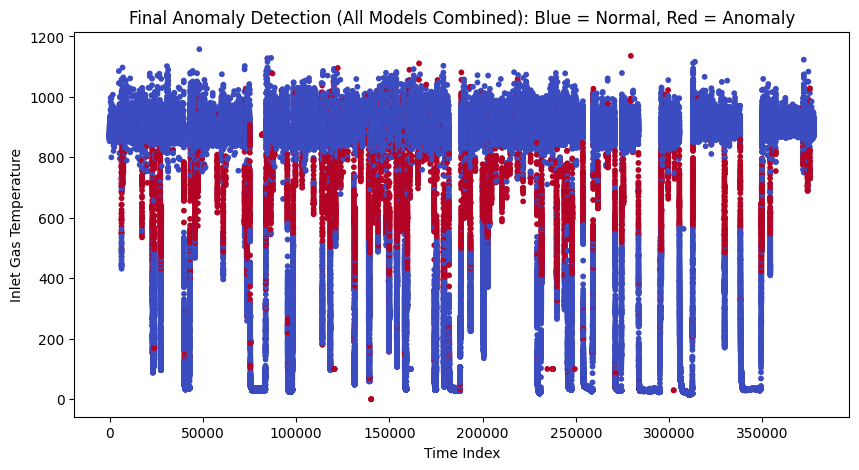

In [15]:
plt.figure(figsize=(10,5))
plt.scatter(
    X_cleaned.index,
    X_cleaned['Cyclone_Inlet_Gas_Temp'],
    c=df.loc[X_cleaned.index, 'Final_Anomaly'],
    cmap='coolwarm',
    s=10
)
plt.title("Final Anomaly Detection (All Models Combined): Blue = Normal, Red = Anomaly")
plt.xlabel("Time Index")
plt.ylabel("Inlet Gas Temperature")
plt.show()